In [68]:
import warnings
import pandas as pd
warnings.filterwarnings('ignore')

EVENT_IDS = pd.read_csv('./data/test.csv')['event_id']

<h1>BEST MODEL v1</h1>
<code>
BEST_FEATURES = ['cross_track_component', 'log_ratio_epsilonp']

BEST_EPSILON  = 1e-6

BEST_TRAIN    = 'train_best.csv'

BEST_TEST     = 'test_best.csv'
</code>

In [69]:
def save_submission(filename, submission):
    """
    Saves a DataFrame of probability predictions as a CSV file in the 'submission' directory
    after all necessary checks for format, column names, probability validity, and event_id matching.

    :param filename: Name of the file as a string (without .csv extension)
    :param submission: DataFrame of probability predictions
    :return: Nothing except a message confirming the save location
    """

    # Ensure the filename does not include '.csv' and is a valid string
    assert not str(filename).lower().endswith('.csv'), (
        "Filename must NOT include '.csv'. Pass a base name like 'test_submission_platt_scaled'."
    )

    # Ensure that the submission is a DataFrame
    assert isinstance(submission, pd.DataFrame), "Submission must be a pandas DataFrame."

    # Ensure that the submission contains the correct columns
    required_cols = ['event_id', 'prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']

    assert list(submission.columns) == required_cols, f"Column mismatch. Expected {required_cols}, got {list(submission.columns)}"

    # Check all probabilities are valid (between 0 and 1) and contain no NaNs
    for col in ['prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']:
        assert submission[col].between(0, 1).all(), f"Invalid probabilities in {col}"
        assert submission[col].isna().sum() == 0, f"NaNs found in {col}"

    # Check that event IDs match exactly
    assert submission['event_id'].tolist() == EVENT_IDS.tolist(), "event_id column must match the test set event_ids in order and length."

    # If all checks pass, save the submission
    submission.to_csv(f'submissions/{filename}.csv', index=False)
    print(f'✓ Submission saved to \'./submissions/{filename}.csv\'')

In [70]:
train = pd.read_csv('./data/train.csv')
TARGETS = ['time_to_hit_hours', 'event']
FEATURES = [col for col in train.columns if col not in TARGETS + ['event_id', 'log1p_area_first']]
full_train_data = train[TARGETS + FEATURES].copy()

# K-Fold cross validation

In [71]:
import numpy as np
from sklearn.model_selection import KFold
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sksurv.metrics import brier_score
from sksurv.util import Surv

HORIZONS = [24, 48, 72]
HORIZON_WEIGHTS = [0.3, 0.4, 0.3]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(full_train_data)):
    train_fold = full_train_data.iloc[train_idx]
    val_fold = full_train_data.iloc[val_idx]

    # Fit model
    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(train_fold, duration_col='time_to_hit_hours', event_col='event')

    # --- C-index ---
    c_idx = concordance_index(
        val_fold['time_to_hit_hours'],
        -cph.predict_partial_hazard(val_fold),
        val_fold['event']
    )

    # --- Brier Score at each horizon ---
    # sksurv needs structured arrays
    train_surv = Surv.from_arrays(
        event=train_fold['event'].astype(bool),
        time=train_fold['time_to_hit_hours']
    )
    val_surv = Surv.from_arrays(
        event=val_fold['event'].astype(bool),
        time=val_fold['time_to_hit_hours']
    )

    # Get survival probabilities at each horizon
    surv_funcs = cph.predict_survival_function(val_fold)

    brier_scores = []
    for h, w in zip(HORIZONS, HORIZON_WEIGHTS):
        # Only evaluate at horizons within the observed time range
        max_time = val_fold['time_to_hit_hours'].max()

        if h > max_time:
            print(f"Skipping horizon {h}h (exceeds max validation time {max_time:.2f}h)")
            continue

        # Extract predicted probability of event by horizon h
        # = 1 - S(h)
        pred_probs = 1 - cph.predict_survival_function(val_fold, times=[h]).values.flatten()

        _, bs = brier_score(train_surv, val_surv, pred_probs, [h])

        brier_scores.append((h, w, bs[0]))

    # Weighted Brier
    total_weight = sum(w for _, w, _ in brier_scores)
    weighted_brier = sum(w * bs for _, w, bs in brier_scores) / total_weight

    # Hybrid score
    hybrid = 0.3 * c_idx + 0.7 * (1 - weighted_brier)

    fold_scores.append({
        'fold': fold + 1,
        'c_index': c_idx,
        **{f'brier_{h}h': bs for h, _, bs in brier_scores},
        'weighted_brier': weighted_brier,
        'hybrid': hybrid
    })

    print(f"Fold {fold+1}: C-index={c_idx:.3f} | "
          + " | ".join(f"Brier@{h}h={bs:.3f}" for h, _, bs in brier_scores)
          + f" | Weighted Brier={weighted_brier:.3f} | Hybrid={hybrid:.3f}")

# Summary
print("\n" + "="*60)
print("CROSS-VALIDATION SUMMARY")
print("="*60)
for metric in ['c_index', 'brier_24h', 'brier_48h', 'brier_72h', 'weighted_brier', 'hybrid']:
    vals = [f[metric] for f in fold_scores if metric in f]
    print(f"{metric:20s}: {np.mean(vals):.3f} ± {np.std(vals):.3f}")

Skipping horizon 72h (exceeds max validation time 66.66h)
Fold 1: C-index=0.820 | Brier@24h=0.528 | Brier@48h=0.542 | Weighted Brier=0.536 | Hybrid=0.571
Skipping horizon 72h (exceeds max validation time 66.79h)
Fold 2: C-index=0.912 | Brier@24h=0.584 | Brier@48h=0.621 | Weighted Brier=0.605 | Hybrid=0.550
Skipping horizon 72h (exceeds max validation time 66.97h)
Fold 3: C-index=0.769 | Brier@24h=0.568 | Brier@48h=0.576 | Weighted Brier=0.573 | Hybrid=0.530
Skipping horizon 72h (exceeds max validation time 66.92h)
Fold 4: C-index=0.866 | Brier@24h=0.620 | Brier@48h=0.613 | Weighted Brier=0.616 | Hybrid=0.528
Skipping horizon 72h (exceeds max validation time 66.99h)
Fold 5: C-index=0.898 | Brier@24h=0.560 | Brier@48h=0.493 | Weighted Brier=0.521 | Hybrid=0.604

CROSS-VALIDATION SUMMARY
c_index             : 0.853 ± 0.053
brier_24h           : 0.572 ± 0.030
brier_48h           : 0.569 ± 0.047
brier_72h           : nan ± nan
weighted_brier      : 0.570 ± 0.037
hybrid              : 0.557 

In [72]:
# Fit model on FULL training data
cph_full = CoxPHFitter(penalizer=0.1)
cph_full.fit(full_train_data, duration_col='time_to_hit_hours', event_col='event')

<lifelines.CoxPHFitter: fitted with 221 total observations, 152 right-censored observations>

Mean predicted probability of event by 48h: 0.340
25th percentile: 0.130
50th percentile (median): 0.281
75th percentile: 0.397
90th percentile: 0.789


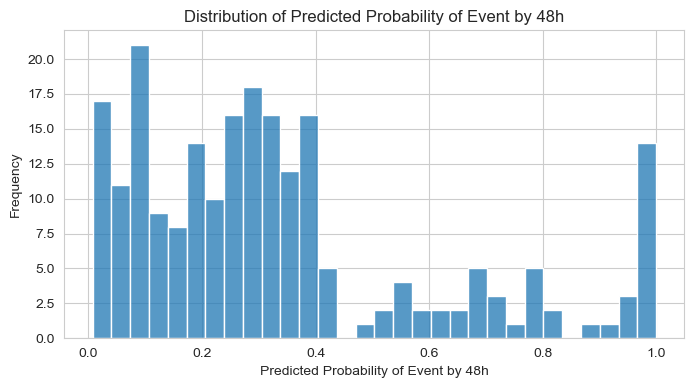

In [73]:
# Get predicted probability of event by 48h for full training data
pred_probs_48 = 1 - cph_full.predict_survival_function(full_train_data, times=[48]).values.flatten()
# print the mean, quartiles, 75th and 90th percentiles of the predicted probabilities
print(f"Mean predicted probability of event by 48h: {pred_probs_48.mean():.3f}")
print(f"25th percentile: {np.percentile(pred_probs_48, 25):.3f}")
print(f"50th percentile (median): {np.percentile(pred_probs_48, 50):.3f}")
print(f"75th percentile: {np.percentile(pred_probs_48, 75):.3f}")
print(f"90th percentile: {np.percentile(pred_probs_48, 90):.3f}")
# plot the distribution of the continuous variable 'pred_probs_48'
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.histplot(pred_probs_48, bins=30)
plt.title('Distribution of Predicted Probability of Event by 48h')
plt.xlabel('Predicted Probability of Event by 48h')
plt.ylabel('Frequency')
plt.show()

count    221.000000
mean       0.568902
std        0.292201
min        0.020014
25%        0.320972
50%        0.601815
75%        0.756551
max        1.000000
dtype: float64


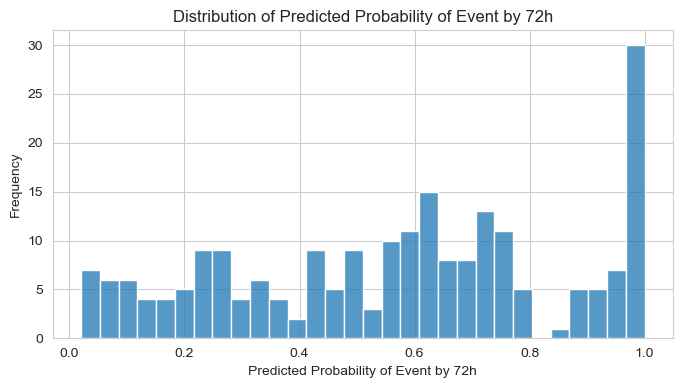

In [74]:
pred_probs_72 = 1 - cph_full.predict_survival_function(full_train_data, times=[72]).values.flatten()
print(pd.Series(pred_probs_72).describe())
plt.figure(figsize=(8, 4))
sns.histplot(pred_probs_72, bins=30)
plt.title('Distribution of Predicted Probability of Event by 72h')
plt.xlabel('Predicted Probability of Event by 72h')
plt.ylabel('Frequency')
plt.show()

In [75]:
# Display Cox model feature importance
print("="*80)
print("COX MODEL FEATURE IMPORTANCE")
print("="*80)
print(cph_full.summary)

print("\n" + "="*80)
print("TOP 15 FEATURES BY ABSOLUTE COEFFICIENT MAGNITUDE")
print("="*80)
feature_importance = cph_full.summary[['coef', 'exp(coef)', 'p']].copy()
feature_importance['abs_coef'] = feature_importance['coef'].abs()
feature_importance_sorted = feature_importance.sort_values('abs_coef', ascending=False)
print(feature_importance_sorted.head(15))

print(f"\n{'='*80}")
print(f"Significant features (p < 0.05): {(feature_importance['p'] < 0.05).sum()}/{len(feature_importance)}")
print(f"Marginally significant (0.05 ≤ p < 0.10): {((feature_importance['p'] >= 0.05) & (feature_importance['p'] < 0.10)).sum()}/{len(feature_importance)}")
print(f"Not significant (p ≥ 0.10): {(feature_importance['p'] >= 0.10).sum()}/{len(feature_importance)}")

COX MODEL FEATURE IMPORTANCE
                                  coef  exp(coef)      se(coef)  \
covariate                                                         
num_perimeters_0_5h           0.097630   1.102555  5.841784e-02   
dt_first_last_0_5h            0.021597   1.021832  8.856417e-02   
low_temporal_resolution_0_5h -0.324712   0.722736  3.556698e-01   
area_first_ha                -0.000150   0.999850  1.077273e-04   
area_growth_abs_0_5h         -0.000101   0.999899  1.003086e-03   
area_growth_rel_0_5h          0.019070   1.019253  1.405367e-01   
area_growth_rate_ha_per_h    -0.000082   0.999918  4.693629e-03   
log1p_growth                  0.149625   1.161399  1.241596e-01   
log_area_ratio_0_5h          -0.270010   0.763372  5.941531e-01   
relative_growth_0_5h          0.019070   1.019253  1.405367e-01   
radial_growth_m              -0.000108   0.999892  1.347402e-03   
radial_growth_rate_m_per_h    0.000340   1.000340  5.136420e-03   
centroid_displacement_m      -0.0

In [76]:
# Load test data and generate predictions for submission
test = pd.read_csv('./data/test.csv')

# Check max observed time in training data
max_observed = train['time_to_hit_hours'].max()
print(f"Max observed time in training data: {max_observed:.2f}h")

# Prepare test data with same features
test_features = test[FEATURES].copy()

# Generate predictions at all required horizons (12h, 24h, 48h, 72h)
submission_horizons = [12, 24, 48, 72]
predictions = {'event_id': test['event_id']}

for h in submission_horizons:
    if h > max_observed:
        print(f"⚠️ WARNING: Predicting at {h}h but max observed time is {max_observed:.2f}h (extrapolation)")

    # Predict probability of event by horizon h
    pred_probs = 1 - cph_full.predict_survival_function(test_features, times=[h]).values.flatten()
    predictions[f'prob_{h}h'] = pred_probs

    print(f"Predictions at {h}h: mean={pred_probs.mean():.3f}, min={pred_probs.min():.3f}, max={pred_probs.max():.3f}")

# Save to CSV
submission = pd.DataFrame(predictions)
save_submission("test_submission", submission)

print(f"  Shape: {submission.shape}")
print(f"\nFirst few rows:")
print(submission.head())

Max observed time in training data: 66.99h
Predictions at 12h: mean=0.220, min=0.005, max=0.995
Predictions at 24h: mean=0.297, min=0.007, max=1.000
Predictions at 48h: mean=0.318, min=0.008, max=1.000
⚠️ WARNING: Predicting at 72h but max observed time is 66.99h (extrapolation)
Predictions at 72h: mean=0.560, min=0.023, max=1.000
✓ Submission saved to './submissions/test_submission.csv'
  Shape: (95, 5)

First few rows:
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602  0.122313  0.185719  0.204560  0.471853
1  13353600  0.254921  0.370853  0.403212  0.763041
2  13942327  0.159744  0.239730  0.263107  0.573284
3  16112781  0.225258  0.330962  0.360911  0.713164
4  17132808  0.712029  0.859197  0.887384  0.997738


In [77]:
from sklearn.preprocessing import StandardScaler
def evaluate_custom_features(feature_list, data, feature_name="Custom Features", standardise=False):
    """
    Run 5-fold cross-validation on CPH model with specified features.

    Parameters:
    -----------
    feature_list : list of feature column names to use
    data : pd.DataFrame
        Full training data (must contain TARGETS columns)
    feature_name : str
        Name for printing/logging purposes
    standardise : bool
        Whether to standardise features within each fold (default: False)

    Returns:
    --------
    list : fold_scores with CV results
    """
    print("="*80)
    print(f"CROSS-VALIDATION: {feature_name}")
    print(f"Features: {len(feature_list)}")
    print("="*80)

    # Create dataset with specified features
    data_subset = data[TARGETS + feature_list].copy()

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores_custom = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(data_subset)):
        train_fold = data_subset.iloc[train_idx].copy()
        val_fold = data_subset.iloc[val_idx].copy()

        standardiser = StandardScaler()

        if standardise:
            train_fold[feature_list] = standardiser.fit_transform(train_fold[feature_list])
            val_fold[feature_list] = standardiser.transform(val_fold[feature_list])

        # Fit model
        cph = CoxPHFitter(penalizer=0.1)
        cph.fit(train_fold, duration_col='time_to_hit_hours', event_col='event')

        # --- C-index ---
        c_idx = concordance_index(
            val_fold['time_to_hit_hours'],
            -cph.predict_partial_hazard(val_fold),
            val_fold['event']
        )

        # --- Brier Score at each horizon ---
        train_surv = Surv.from_arrays(
            event=train_fold['event'].astype(bool),
            time=train_fold['time_to_hit_hours']
        )
        val_surv = Surv.from_arrays(
            event=val_fold['event'].astype(bool),
            time=val_fold['time_to_hit_hours']
        )

        brier_scores = []
        for h, w in zip(HORIZONS, HORIZON_WEIGHTS):
            max_time = val_fold['time_to_hit_hours'].max()

            if h > max_time:
                continue

            pred_probs = 1 - cph.predict_survival_function(val_fold, times=[h]).values.flatten()
            _, bs = brier_score(train_surv, val_surv, pred_probs, [h])
            brier_scores.append((h, w, bs[0]))

        # Weighted Brier
        total_weight = sum(w for _, w, _ in brier_scores)
        weighted_brier = sum(w * bs for _, w, bs in brier_scores) / total_weight

        # Hybrid score
        hybrid = 0.3 * c_idx + 0.7 * (1 - weighted_brier)

        fold_scores_custom.append({
            'fold': fold + 1,
            'c_index': c_idx,
            **{f'brier_{h}h': bs for h, _, bs in brier_scores},
            'weighted_brier': weighted_brier,
            'hybrid': hybrid
        })

        print(f"Fold {fold+1}: C-index={c_idx:.3f} | "
              + " | ".join(f"Brier@{h}h={bs:.3f}" for h, _, bs in brier_scores)
              + f" | Weighted Brier={weighted_brier:.3f} | Hybrid={hybrid:.3f}")

    # Summary
    print("\n" + "="*80)
    print(f"CROSS-VALIDATION SUMMARY - {feature_name}")
    print("="*80)
    for metric in ['c_index', 'brier_24h', 'brier_48h', 'brier_72h', 'weighted_brier', 'hybrid']:
        vals = [f[metric] for f in fold_scores_custom if metric in f]
        if vals:
            print(f"{metric:20s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

    return fold_scores_custom


def train_and_submit(feature_list, data, test_data, filename_suffix=""):
    """
    Train CPH model on full dataset with specified features and generate test submission.

    Parameters:
    -----------
    feature_list : list
        List of feature column names to use
    data : pd.DataFrame
        Full training data (must contain TARGETS columns)
    test_data : pd.DataFrame
        Test data
    filename_suffix : str
        Suffix for submission filename (e.g., "_significant" creates "test_submission_significant.csv")

    Returns:
    --------
    tuple : (cph_model, submission_df)
    """
    print("="*80)
    print(f"TRAINING MODEL ON FULL DATASET")
    print(f"Features: {len(feature_list)}")
    print("="*80)

    # Fit model on full training data
    data_subset = data[TARGETS + feature_list].copy()
    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(data_subset, duration_col='time_to_hit_hours', event_col='event')

    print("\nModel trained successfully!")

    # Prepare test data with same features
    test_features = test_data[feature_list].copy()

    # Generate predictions at all required horizons (12h, 24h, 48h, 72h)
    submission_horizons = [12, 24, 48, 72]
    predictions = {'event_id': test_data['event_id']}

    max_observed = data['time_to_hit_hours'].max()

    for h in submission_horizons:
        if h > max_observed:
            print(f"⚠️  WARNING: Predicting at {h}h but max observed time is {max_observed:.2f}h (extrapolation)")

        # Predict probability of event by horizon h
        pred_probs = 1 - cph.predict_survival_function(test_features, times=[h]).values.flatten()
        predictions[f'prob_{h}h'] = pred_probs

        print(f"Predictions at {h}h: mean={pred_probs.mean():.3f}, min={pred_probs.min():.3f}, max={pred_probs.max():.3f}")

    # Create submission dataframe and save to CSV file
    submission = pd.DataFrame(predictions)
    filename = f'test_submission{filename_suffix}'
    save_submission(filename, submission)

    print(f"  Shape: {submission.shape}")
    print(f"\nFirst few rows:")
    print(submission.head())

    return cph, submission


In [78]:
# Extract significant features (p < 0.1) from the baseline model
SIGNIFICANT_FEATURES = feature_importance[feature_importance['p'] < 0.1].index.tolist()

print("="*80)
print("SIGNIFICANT FEATURES (p < 0.1)")
print("="*80)
print(f"Count: {len(SIGNIFICANT_FEATURES)}")
print(f"Features: {SIGNIFICANT_FEATURES}")
print()

# Run cross-validation with significant features only
fold_scores_significant = evaluate_custom_features(
    SIGNIFICANT_FEATURES,
    full_train_data,
    feature_name="Significant Features (p < 0.1)"
)

# Compare with baseline
print("\n" + "="*80)
print("COMPARISON: ALL FEATURES vs SIGNIFICANT ONLY")
print("="*80)
print(f"{'Metric':<25} {'All Features':<20} {'Significant Only':<20} {'Difference':<15}")
print("-" * 80)
for metric in ['c_index', 'brier_24h', 'brier_48h', 'brier_72h', 'weighted_brier', 'hybrid']:
    all_vals = [f[metric] for f in fold_scores if metric in f]
    sig_vals = [f[metric] for f in fold_scores_significant if metric in f]
    if all_vals and sig_vals:
        all_mean = np.mean(all_vals)
        sig_mean = np.mean(sig_vals)
        diff = sig_mean - all_mean
        print(f"{metric:<25} {all_mean:<20.4f} {sig_mean:<20.4f} {diff:+.4f}")

print("\n")

# Generate test submission with significant features only
cph_significant, submission_significant = train_and_submit(
    SIGNIFICANT_FEATURES,
    full_train_data,
    test,
    filename_suffix="_significant"
)


SIGNIFICANT FEATURES (p < 0.1)
Count: 3
Features: ['num_perimeters_0_5h', 'dist_min_ci_0_5h', 'cross_track_component']

CROSS-VALIDATION: Significant Features (p < 0.1)
Features: 3
Fold 1: C-index=0.924 | Brier@24h=0.548 | Brier@48h=0.543 | Weighted Brier=0.545 | Hybrid=0.596
Fold 2: C-index=0.947 | Brier@24h=0.497 | Brier@48h=0.519 | Weighted Brier=0.510 | Hybrid=0.627
Fold 3: C-index=0.835 | Brier@24h=0.529 | Brier@48h=0.553 | Weighted Brier=0.543 | Hybrid=0.570
Fold 4: C-index=0.907 | Brier@24h=0.545 | Brier@48h=0.525 | Weighted Brier=0.533 | Hybrid=0.599
Fold 5: C-index=0.940 | Brier@24h=0.508 | Brier@48h=0.457 | Weighted Brier=0.479 | Hybrid=0.647

CROSS-VALIDATION SUMMARY - Significant Features (p < 0.1)
c_index             : 0.9106 ± 0.0403
brier_24h           : 0.5255 ± 0.0201
brier_48h           : 0.5196 ± 0.0336
weighted_brier      : 0.5221 ± 0.0251
hybrid              : 0.6077 ± 0.0266

COMPARISON: ALL FEATURES vs SIGNIFICANT ONLY
Metric                    All Features      

The three significant features are:
- num_perimeters_0_5h
- dist_min_ci_0_5h
- cross_track_component

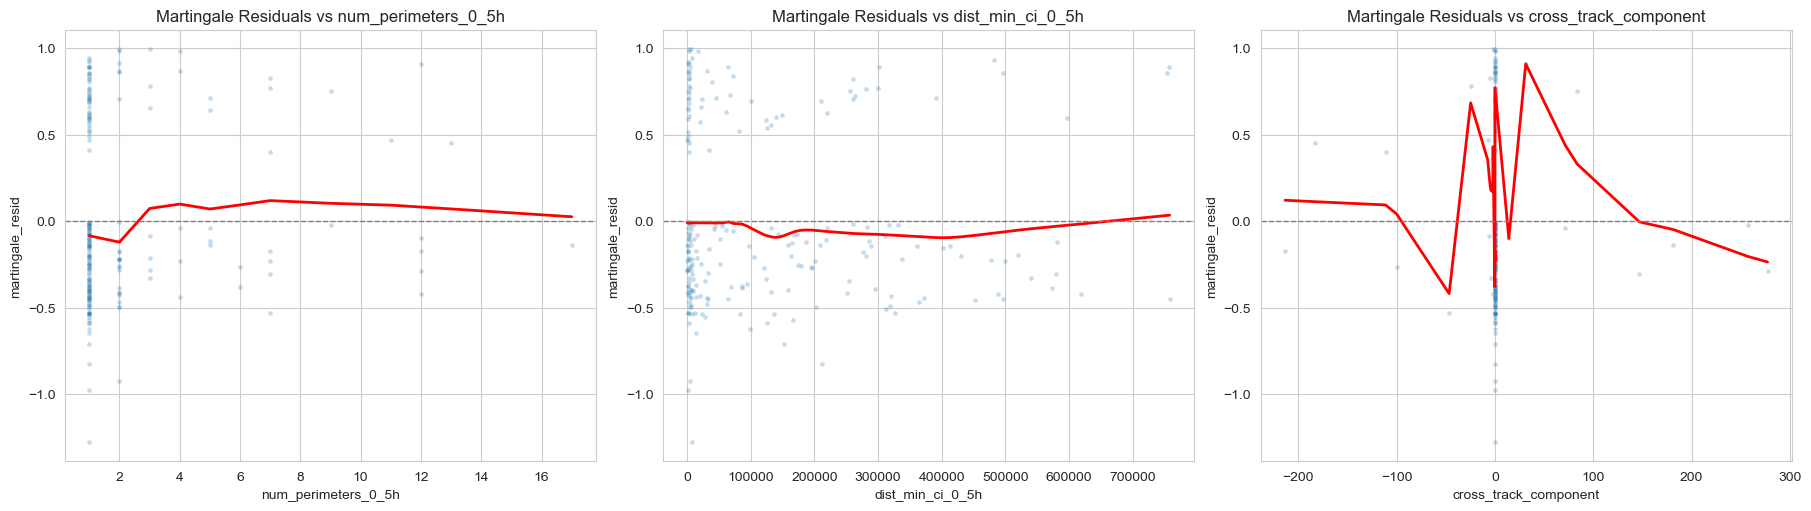

Interpretation: smooth curve close to flat around 0 suggests linear form is adequate;
systematic curvature suggests a nonlinear transform or interaction may help.


In [79]:
# Martingale residual diagnostics (no binning)
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import CoxPHFitter

DIAGNOSTIC_FEATURES = ["num_perimeters_0_5h", "dist_min_ci_0_5h", "cross_track_component"]
diag_df = train[TARGETS + DIAGNOSTIC_FEATURES].dropna().copy()

# 1) Fit Cox model on the 3 selected features
cph_diag = CoxPHFitter(penalizer=0.1)
cph_diag.fit(diag_df, duration_col="time_to_hit_hours", event_col="event")

# 2) Compute martingale residuals for each row
martingale_df = cph_diag.compute_residuals(diag_df, kind="martingale")
resid_col = "martingale" if "martingale" in martingale_df.columns else martingale_df.select_dtypes(include=["number"]).columns[0]
diag_df["martingale_resid"] = martingale_df[resid_col].values

# 3-4) Plot residuals vs each feature with smooth trend line (LOWESS), no binning
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, feature in zip(axes, DIAGNOSTIC_FEATURES):
    sns.scatterplot(data=diag_df, x=feature, y="martingale_resid", s=12, alpha=0.25, ax=ax)
    sns.regplot(
        data=diag_df,
        x=feature,
        y="martingale_resid",
        scatter=False,
        lowess=True,
        line_kws={"color": "red", "lw": 2},
        ax=ax,
    )
    ax.axhline(0, color="gray", linestyle="--", lw=1)
    ax.set_title(f"Martingale Residuals vs {feature}")

plt.show()

# 5) Interpretation guide for smooth curves
print("Interpretation: smooth curve close to flat around 0 suggests linear form is adequate;")
print("systematic curvature suggests a nonlinear transform or interaction may help.")


In [80]:
# Train and submit with only the two requested features
TOP2_FEATURES = ['num_perimeters_0_5h', 'dist_min_ci_0_5h']

cph_top2, submission_top2 = train_and_submit(
    TOP2_FEATURES,
    full_train_data,
    test,
    filename_suffix='_top2'
)

TRAINING MODEL ON FULL DATASET
Features: 2

Model trained successfully!
Predictions at 12h: mean=0.230, min=0.006, max=0.999
Predictions at 24h: mean=0.305, min=0.008, max=1.000
Predictions at 48h: mean=0.326, min=0.009, max=1.000
⚠️  WARNING: Predicting at 72h but max observed time is 66.99h (extrapolation)
Predictions at 72h: mean=0.568, min=0.023, max=1.000
✓ Submission saved to './submissions/test_submission_top2.csv'
  Shape: (95, 5)

First few rows:
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602  0.156267  0.222083  0.240969  0.494990
1  13353600  0.267044  0.368187  0.395949  0.713232
2  13942327  0.243249  0.337638  0.363810  0.673926
3  16112781  0.267443  0.368696  0.396484  0.713860
4  17132808  0.530116  0.672501  0.706392  0.952004


In [81]:
# Raw-ratio model + residual comparison on raw vs log-transformed ratio

RATIO_RAW_COL = 'num_perimeters_dist_min_ratio_raw'
RATIO_LOG_COL = 'num_perimeters_dist_min_ratio_log'

BASE_FEATURES = ['num_perimeters_0_5h', 'dist_min_ci_0_5h', 'cross_track_component']
SCALED_FEATURES = BASE_FEATURES + [RATIO_RAW_COL]

train_scaled_df = train.copy()

# 1) Engineer raw ratio and keep this as the model feature
train_scaled_df[RATIO_RAW_COL] = (
    train_scaled_df['num_perimeters_0_5h']
    / train_scaled_df['dist_min_ci_0_5h'].replace(0, np.nan)
)

# 2) Clean + impute model features (raw ratio included)
train_scaled_df[SCALED_FEATURES] = train_scaled_df[SCALED_FEATURES].replace([np.inf, -np.inf], np.nan)
train_feature_medians = train_scaled_df[SCALED_FEATURES].median()
train_scaled_df[SCALED_FEATURES] = train_scaled_df[SCALED_FEATURES].fillna(train_feature_medians)

# 3) Standardize features and fit Cox on raw-ratio feature set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_scaled_df[SCALED_FEATURES])

train_model_df = pd.DataFrame(X_train_scaled, columns=SCALED_FEATURES, index=train_scaled_df.index)
train_model_df[TARGETS] = train_scaled_df[TARGETS]

cph_scaled_ratio = CoxPHFitter(penalizer=0.1)
cph_scaled_ratio.fit(train_model_df[TARGETS + SCALED_FEATURES], duration_col='time_to_hit_hours', event_col='event')

# 4) Compute martingale residuals from the raw-ratio-fitted model
mart_scaled_ratio = cph_scaled_ratio.compute_residuals(
    train_model_df[TARGETS + SCALED_FEATURES],
    kind='martingale'
)
mart_col = 'martingale' if 'martingale' in mart_scaled_ratio.columns else mart_scaled_ratio.select_dtypes(include=['number']).columns[0]

# 5) Build comparison x-axes using the same residuals: raw ratio vs log(epsilon + raw ratio)
ratio_diag_raw = pd.DataFrame({
    RATIO_RAW_COL: train_scaled_df[RATIO_RAW_COL],
    'martingale_resid': mart_scaled_ratio[mart_col].values,
}).replace([np.inf, -np.inf], np.nan).dropna()

In [82]:
def plot_log_epsilon_p(raw_ratios, RAW_RATIO, LOG_RATIO, axes, epsilon=1):
    ratio_diag_log = raw_ratios.copy()
    ratio_diag_log[LOG_RATIO] = np.log(epsilon + ratio_diag_log[RAW_RATIO])
    ratio_diag_log = ratio_diag_log.replace([np.inf, -np.inf], np.nan).dropna(subset=[LOG_RATIO, 'martingale_resid'])
    # Plot 2: Log-transformed ratio
    sns.scatterplot(
        data=ratio_diag_log,
        x=LOG_RATIO,
        y='martingale_resid',
        s=12,
        alpha=0.25,
        ax=axes,
    )
    sns.regplot(
        data=ratio_diag_log,
        x=LOG_RATIO,
        y='martingale_resid',
        scatter=False,
        lowess=True,
        line_kws={'color': 'red', 'lw': 2},
        ax=axes,
    )
    axes.axhline(0, color='gray', linestyle='--', lw=1)
    axes.set_title(f'Martingale Residuals vs log({epsilon} + raw_ratio)')
    axes.set_xlabel(LOG_RATIO)
    axes.set_ylabel('Martingale residual')

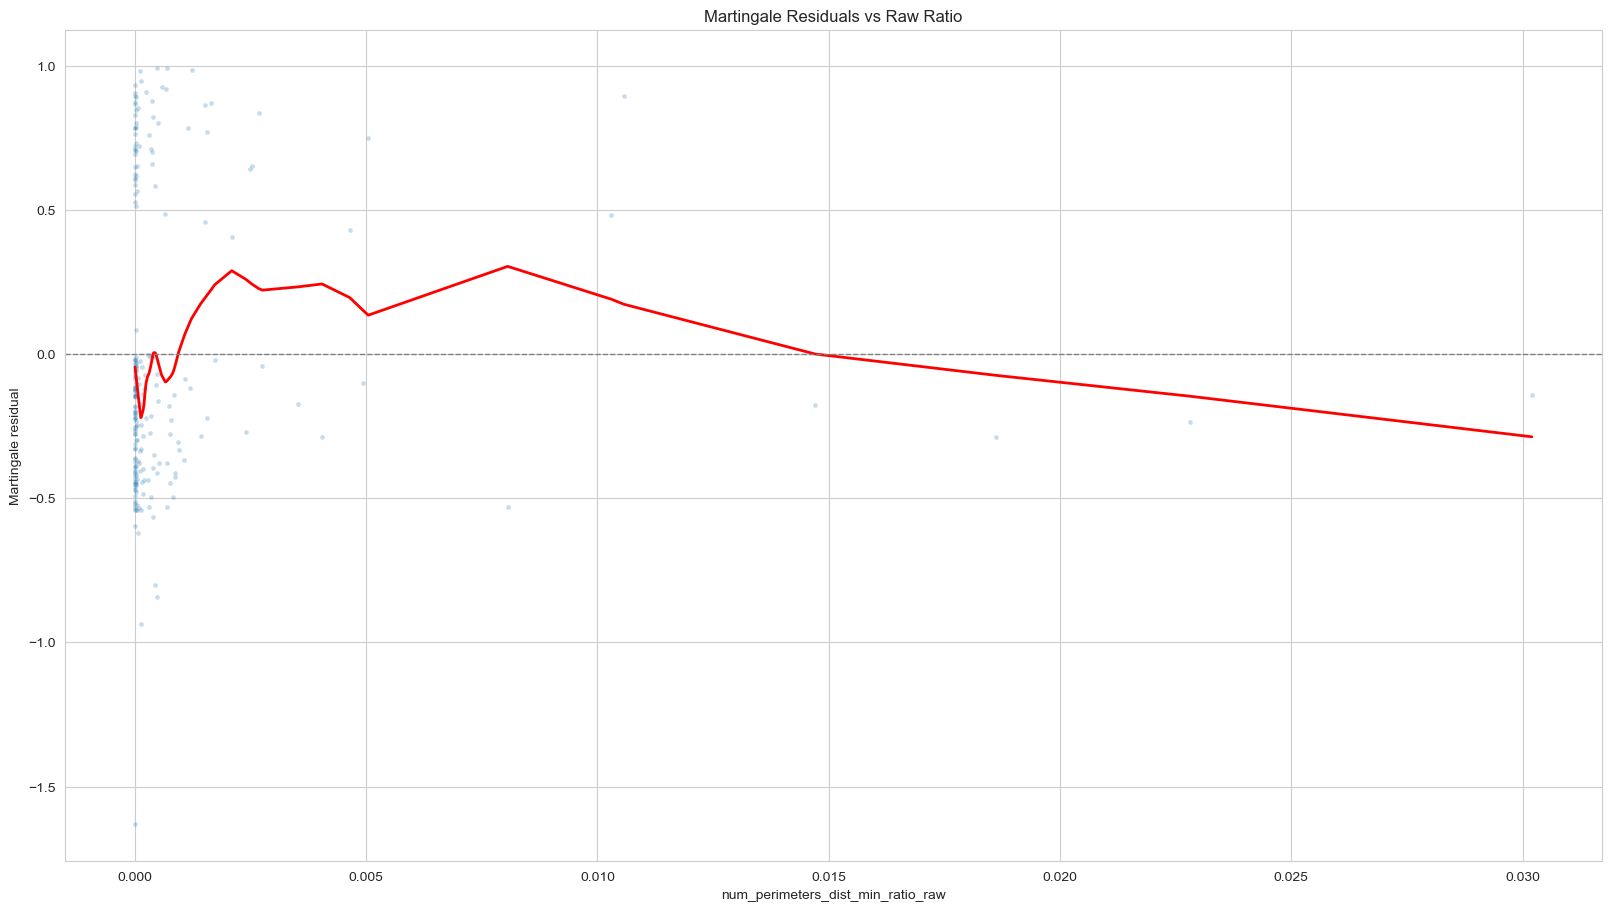

In [83]:
# Subplot: raw vs log-transformed ratio
fig, axes = plt.subplots(figsize=(16, 9), constrained_layout=True)

# Plot 1: Raw ratio
sns.scatterplot(
    data=ratio_diag_raw,
    x=RATIO_RAW_COL,
    y='martingale_resid',
    s=12,
    alpha=0.25,
    ax=axes,
)
sns.regplot(
    data=ratio_diag_raw,
    x=RATIO_RAW_COL,
    y='martingale_resid',
    scatter=False,
    lowess=True,
    line_kws={'color': 'red', 'lw': 2},
    ax=axes,
)
axes.axhline(0, color='gray', linestyle='--', lw=1)
axes.set_title('Martingale Residuals vs Raw Ratio')
axes.set_xlabel(RATIO_RAW_COL)
axes.set_ylabel('Martingale residual')

plt.show()

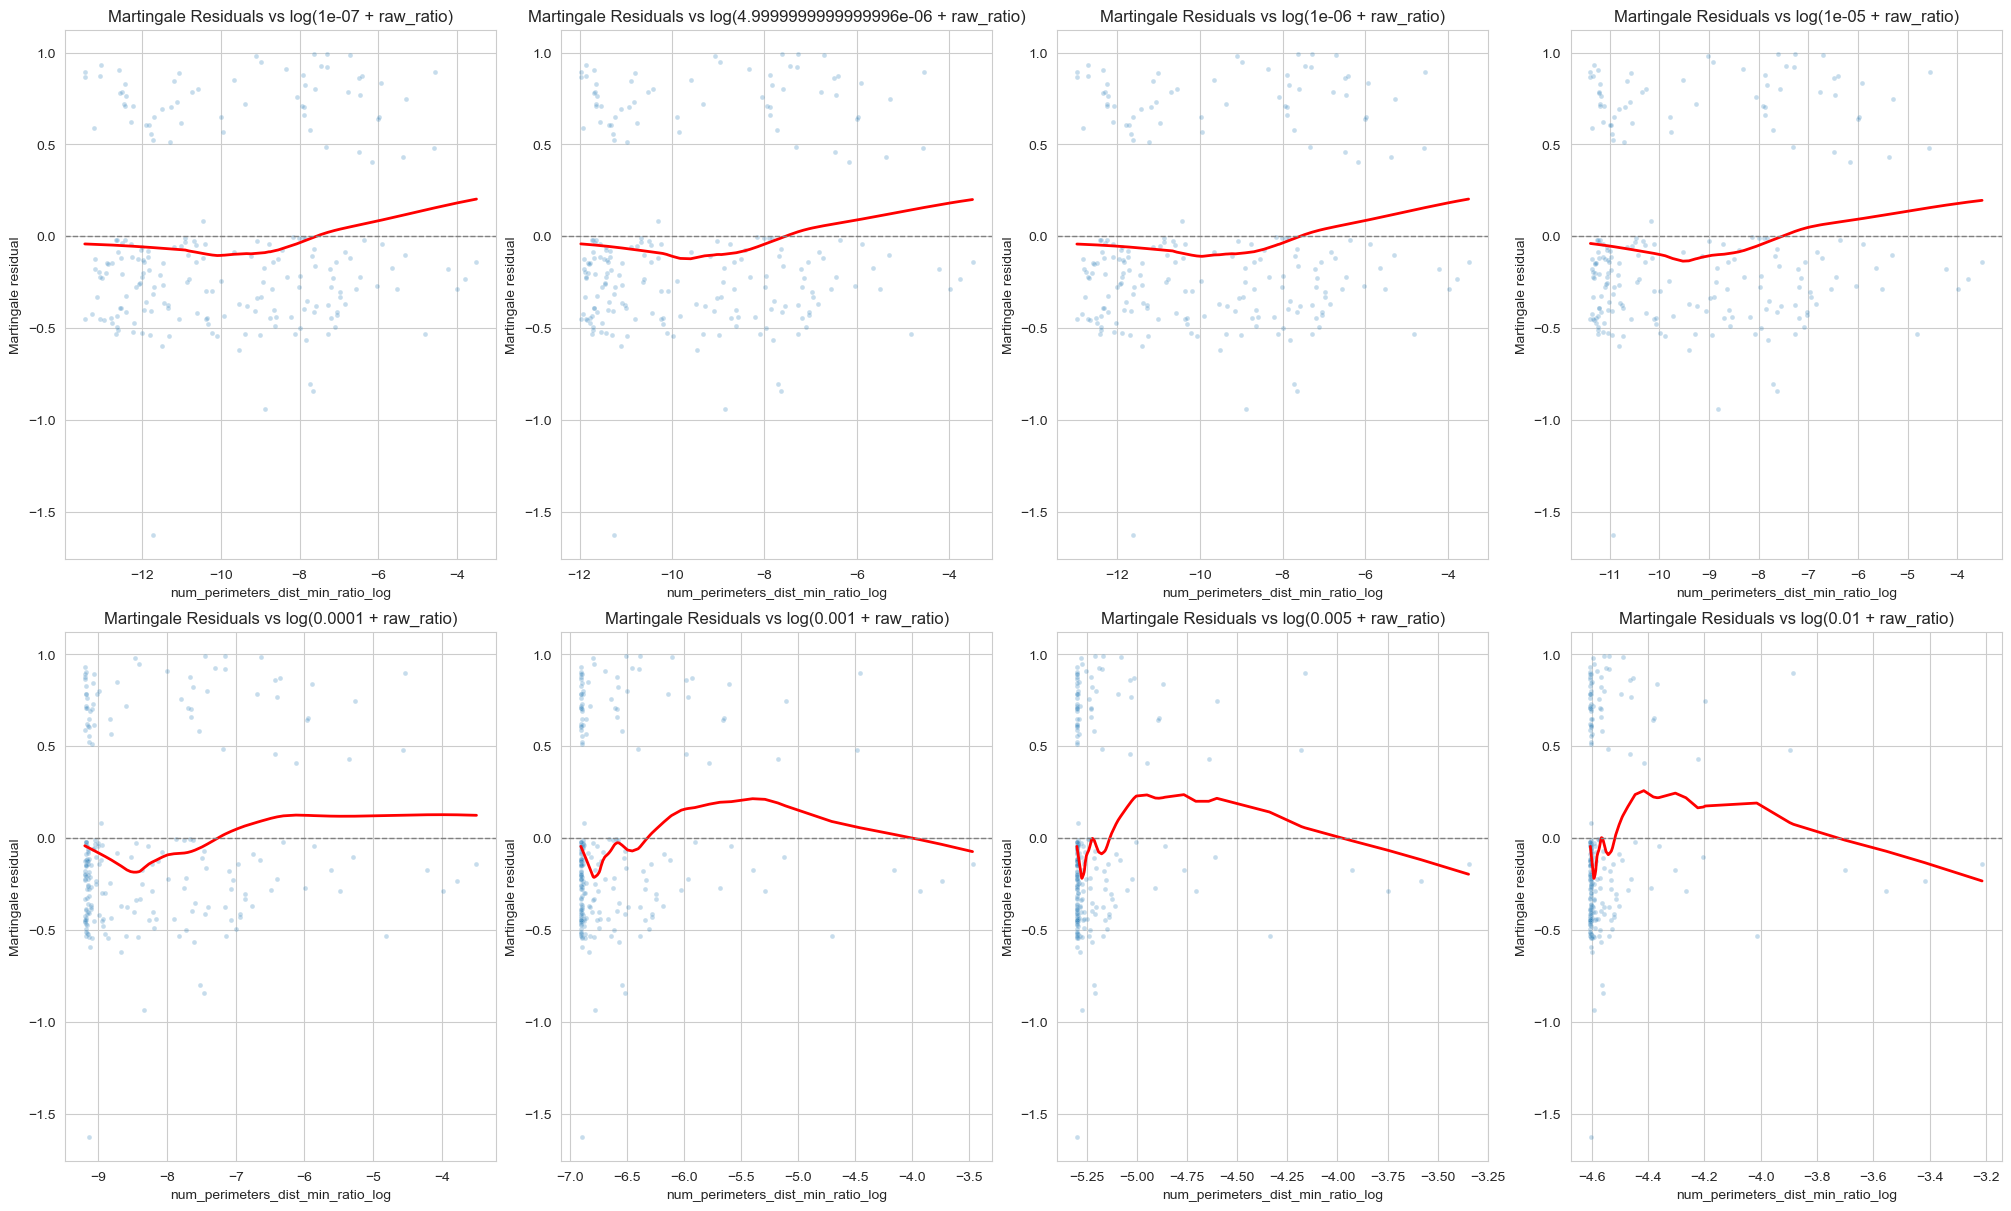

In [84]:
fig_epsilons, axes_epsilons = plt.subplots(nrows=2, ncols=4, figsize=(20, 12), constrained_layout=True)
epsilons = [1e-7, 5 * 1e-6, 1e-6, 1e-5, 1e-4, 0.001, 0.005, 0.01]
# flatten axes for easy iteration
axes_epsilons = axes_epsilons.flatten()
for i in range(len(epsilons)):
    plot_log_epsilon_p(ratio_diag_raw, RATIO_RAW_COL, RATIO_LOG_COL, axes_epsilons[i], epsilon=epsilons[i])
plt.show()

In [85]:
# Submission model: 3 baseline features + log_ratio_epsilonp (epsilon=1e-6)

EPSILON = 1e-6
MODEL_FEATURES = ['num_perimeters_0_5h', 'dist_min_ci_0_5h', 'cross_track_component', 'log_ratio_epsilonp']

train_sub = train.copy()
test_sub = test.copy() if 'test' in globals() else pd.read_csv('./data/test.csv')

# Raw ratio then log(epsilon + x)
train_sub['raw_ratio'] = train_sub['num_perimeters_0_5h'] / train_sub['dist_min_ci_0_5h'].replace(0, np.nan)
test_sub['raw_ratio'] = test_sub['num_perimeters_0_5h'] / test_sub['dist_min_ci_0_5h'].replace(0, np.nan)
train_sub['log_ratio_epsilonp'] = np.log(EPSILON + train_sub['raw_ratio'])
test_sub['log_ratio_epsilonp'] = np.log(EPSILON + test_sub['raw_ratio'])

# Clean and impute using train medians
for df in (train_sub, test_sub):
    df[MODEL_FEATURES] = df[MODEL_FEATURES].replace([np.inf, -np.inf], np.nan)
feature_medians = train_sub[MODEL_FEATURES].median()
train_sub[MODEL_FEATURES] = train_sub[MODEL_FEATURES].fillna(feature_medians)
test_sub[MODEL_FEATURES] = test_sub[MODEL_FEATURES].fillna(feature_medians)

# Standardize all model features after log transform
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_sub[MODEL_FEATURES])
X_test_scaled = scaler.transform(test_sub[MODEL_FEATURES])

train_sub_scaled = pd.DataFrame(X_train_scaled, columns=MODEL_FEATURES, index=train_sub.index)
train_sub_scaled[TARGETS] = train_sub[TARGETS]
test_sub_scaled = pd.DataFrame(X_test_scaled, columns=MODEL_FEATURES, index=test_sub.index)

# Fit CoxPH on scaled features
cph_test_log_ratio = CoxPHFitter(penalizer=0.1)
cph_test_log_ratio.fit(train_sub_scaled[TARGETS + MODEL_FEATURES], duration_col='time_to_hit_hours', event_col='event')

# Predict probabilities by horizon and save submission
submission_horizons = [12, 24, 48, 72]
submission_data = {'event_id': test_sub['event_id']}
for h in submission_horizons:
    submission_data[f'prob_{h}h'] = 1 - cph_test_log_ratio.predict_survival_function(test_sub_scaled[MODEL_FEATURES], times=[h]).values.flatten()

# create submission
submission_log_ratio_e1e6 = pd.DataFrame(submission_data)

save_submission('test_submission_log_ratio_e1e6', submission_log_ratio_e1e6)

print(submission_log_ratio_e1e6.head())


✓ Submission saved to './submissions/test_submission_log_ratio_e1e6.csv'
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602  0.049003  0.082239  0.093795  0.185973
1  13353600  0.352626  0.524174  0.573595  0.831486
2  13942327  0.128900  0.209986  0.237008  0.431717
3  16112781  0.372073  0.548327  0.598341  0.851272
4  17132808  0.402640  0.585232  0.635772  0.878763


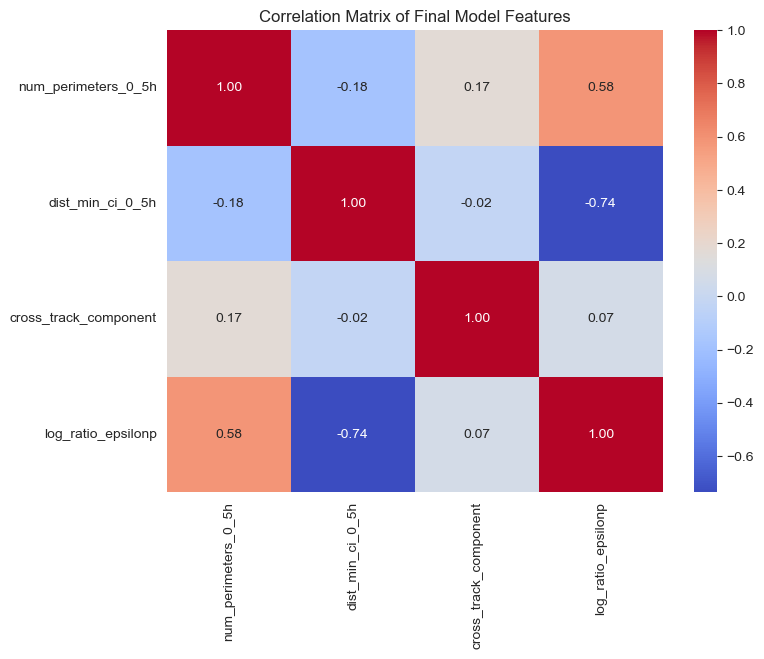

In [86]:
# print the correlation matrix of the final model features
corr_matrix = train_sub_scaled[MODEL_FEATURES].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Final Model Features')
plt.show()

In [87]:
MODEL_FEATURES = ['cross_track_component', 'log_ratio_epsilonp']

train_sub = train.copy()
test_sub = test.copy() if 'test' in globals() else pd.read_csv('./data/test.csv')

# Raw ratio then log(epsilon + x)
train_sub['raw_ratio'] = train_sub['num_perimeters_0_5h'] / train_sub['dist_min_ci_0_5h'].replace(0, np.nan)
test_sub['raw_ratio'] = test_sub['num_perimeters_0_5h'] / test_sub['dist_min_ci_0_5h'].replace(0, np.nan)
train_sub['log_ratio_epsilonp'] = np.log(EPSILON + train_sub['raw_ratio'])
test_sub['log_ratio_epsilonp'] = np.log(EPSILON + test_sub['raw_ratio'])

# Clean and impute using train medians
for df in (train_sub, test_sub):
    df[MODEL_FEATURES] = df[MODEL_FEATURES].replace([np.inf, -np.inf], np.nan)
feature_medians = train_sub[MODEL_FEATURES].median()

# protect against the case where an entry is missing, replace with the median
train_sub[MODEL_FEATURES] = train_sub[MODEL_FEATURES].fillna(feature_medians)
test_sub[MODEL_FEATURES] = test_sub[MODEL_FEATURES].fillna(feature_medians)

# Standardize all model features after log transform
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_sub[MODEL_FEATURES])
X_test_scaled = scaler.transform(test_sub[MODEL_FEATURES])

train_sub_scaled = pd.DataFrame(X_train_scaled, columns=MODEL_FEATURES, index=train_sub.index)
train_sub_scaled[TARGETS] = train_sub[TARGETS]
test_sub_scaled = pd.DataFrame(X_test_scaled, columns=MODEL_FEATURES, index=test_sub.index)

# Fit CoxPH on scaled features
cph_most_optimal = CoxPHFitter(penalizer=0.1)
cph_most_optimal.fit(train_sub_scaled[TARGETS + MODEL_FEATURES], duration_col='time_to_hit_hours', event_col='event')

# Predict probabilities by horizon and save submission
submission_horizons = [12, 24, 48, 72]
submission_data = {'event_id': test_sub['event_id']}
for h in submission_horizons:
    submission_data[f'prob_{h}h'] = 1 - cph_most_optimal.predict_survival_function(test_sub_scaled[MODEL_FEATURES], times=[h]).values.flatten()

submission_log_ratio_e1e6 = pd.DataFrame(submission_data)

save_submission('test_submission_log_ratio_e1e6', submission_log_ratio_e1e6)
print(submission_log_ratio_e1e6.head())

✓ Submission saved to './submissions/test_submission_log_ratio_e1e6.csv'
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602  0.050987  0.084385  0.096013  0.184603
1  13353600  0.362970  0.532168  0.580954  0.827697
2  13942327  0.120909  0.195140  0.220076  0.395004
3  16112781  0.385353  0.559525  0.608890  0.850130
4  17132808  0.343102  0.507327  0.555381  0.805775


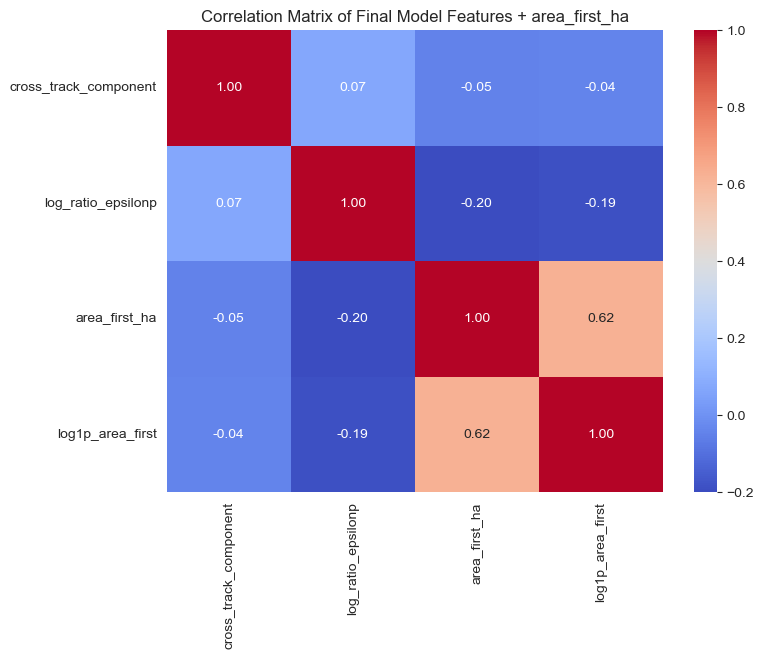

Proportion of zeroes in area_first_ha: 0.00%


In [88]:
MODEL_FEATURES_TEST = MODEL_FEATURES + ['area_first_ha', 'log1p_area_first']
# Check correlation of area_first_ha with the two features
corr_matrix_test = train_sub[MODEL_FEATURES_TEST].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_test, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Final Model Features + area_first_ha')
plt.show()
# print the proportion of zeroes in the area_first_ha feature
zero_proportion = (train_sub['area_first_ha'] == 0).mean()
print(f"Proportion of zeroes in area_first_ha: {zero_proportion:.2%}")

In [89]:
MODEL_FEATURES = ['cross_track_component', 'log_ratio_epsilonp', 'area_first_ha']

train_sub = train.copy()
test_sub = test.copy() if 'test' in globals() else pd.read_csv('./data/test.csv')

# Raw ratio then log(epsilon + x)
train_sub['raw_ratio'] = train_sub['num_perimeters_0_5h'] / train_sub['dist_min_ci_0_5h'].replace(0, np.nan)
test_sub['raw_ratio'] = test_sub['num_perimeters_0_5h'] / test_sub['dist_min_ci_0_5h'].replace(0, np.nan)
train_sub['log_ratio_epsilonp'] = np.log(EPSILON + train_sub['raw_ratio'])
test_sub['log_ratio_epsilonp'] = np.log(EPSILON + test_sub['raw_ratio'])

# Clean and impute using train medians
for df in (train_sub, test_sub):
    df[MODEL_FEATURES] = df[MODEL_FEATURES].replace([np.inf, -np.inf], np.nan)
feature_medians = train_sub[MODEL_FEATURES].median()

# protect against the case where an entry is missing, replace with the median
train_sub[MODEL_FEATURES] = train_sub[MODEL_FEATURES].fillna(feature_medians)
test_sub[MODEL_FEATURES] = test_sub[MODEL_FEATURES].fillna(feature_medians)

# Standardize all model features after log transform
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_sub[MODEL_FEATURES])
X_test_scaled = scaler.transform(test_sub[MODEL_FEATURES])

train_sub_scaled = pd.DataFrame(X_train_scaled, columns=MODEL_FEATURES, index=train_sub.index)
train_sub_scaled[TARGETS] = train_sub[TARGETS]
test_sub_scaled = pd.DataFrame(X_test_scaled, columns=MODEL_FEATURES, index=test_sub.index)

# Fit CoxPH on scaled features
cph_test_area = CoxPHFitter(penalizer=0.1)
cph_test_area.fit(train_sub_scaled[TARGETS + MODEL_FEATURES], duration_col='time_to_hit_hours', event_col='event')

# Predict probabilities by horizon and save submission
submission_horizons = [12, 24, 48, 72]
submission_data = {'event_id': test_sub['event_id']}
for h in submission_horizons:
    submission_data[f'prob_{h}h'] = 1 - cph_test_area.predict_survival_function(test_sub_scaled[MODEL_FEATURES], times=[h]).values.flatten()

# make submission
submission_log_ratio_e1e6 = pd.DataFrame(submission_data)

save_submission('test_submission_log_ratio_e1e6_minimal', submission_log_ratio_e1e6)

✓ Submission saved to './submissions/test_submission_log_ratio_e1e6_minimal.csv'


<h1>Examining Martingale residuals for <code>area_first_ha</code> vs its log transform <code>log1p_area_first</code></h1>
<span style="font-size: 18px">
To investigate whether the relationship between the <code>area_first_ha</code> feature and the hazard is linear or if a transformation like log could improve model fit, we can examine the martingale residuals from a Cox model that includes <code>area_first_ha</code> as a feature.
The steps are as follows:
<ol>
<li>Fit a Cox proportional hazards model using the features <code>cross_track_component</code>, <code>log_ratio_epsilonp</code>, and <code>area_first_ha</code>.</li>
<li>Compute the martingale residuals for each observation in the training data.</li>
<li>Create a scatter plot of the martingale residuals against the <code>area_first_ha</code> feature to visually assess the relationship.</li>
<li>Repeat the process using <code>log1p_area_first</code> instead of <code>area_first_ha</code> to see if the log transformation provides an uncorrelated pattern in the residuals, which would suggest a better capture of that variable's patterns.</li>
</ol>
</span>

MODEL FEATURES (subplot 1): ['cross_track_component', 'log_ratio_epsilonp', 'area_first_ha']
MODEL FEATURES (subplot 2): ['cross_track_component', 'log_ratio_epsilonp', 'log1p_area_first']


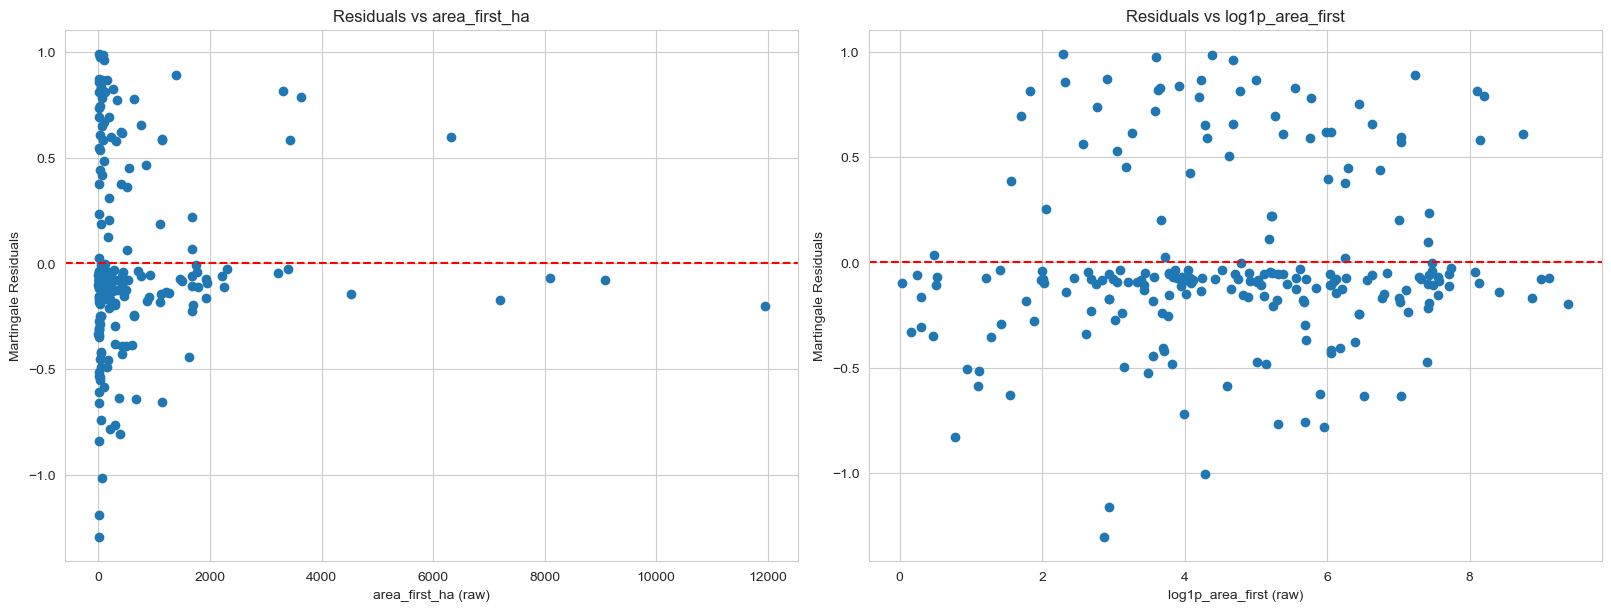

In [90]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), constrained_layout=True)

# FIRST SUBPLOT: model with raw area_first_ha
MODEL_FEATURES = ['cross_track_component', 'log_ratio_epsilonp', 'area_first_ha']
cph_diag = CoxPHFitter(penalizer=0.1)
print('MODEL FEATURES (subplot 1):', MODEL_FEATURES)
cph_diag.fit(train_sub_scaled[TARGETS + MODEL_FEATURES],
             duration_col='time_to_hit_hours',
             event_col='event')

martingale_resid = cph_diag.compute_residuals(
    train_sub_scaled[TARGETS + MODEL_FEATURES],
    kind='martingale'
)

ax[0].scatter(train_sub['area_first_ha'], martingale_resid['martingale'])
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel('area_first_ha (raw)')
ax[0].set_ylabel('Martingale Residuals')
ax[0].set_title('Residuals vs area_first_ha')

# SECOND SUBPLOT: rebuild features + scaling to include log1p_area_first
MODEL_FEATURES_LOG = ['cross_track_component', 'log_ratio_epsilonp', 'log1p_area_first']

train_sub_log = train_sub.copy()

train_sub_log[MODEL_FEATURES_LOG] = train_sub_log[MODEL_FEATURES_LOG].replace([np.inf, -np.inf], np.nan)
log_medians = train_sub_log[MODEL_FEATURES_LOG].median()
train_sub_log[MODEL_FEATURES_LOG] = train_sub_log[MODEL_FEATURES_LOG].fillna(log_medians)

scaler_log = StandardScaler()
X_train_log_scaled = scaler_log.fit_transform(train_sub_log[MODEL_FEATURES_LOG])

train_sub_scaled_log = pd.DataFrame(
    X_train_log_scaled,
    columns=MODEL_FEATURES_LOG,
    index=train_sub_log.index
)
train_sub_scaled_log[TARGETS] = train_sub_log[TARGETS]

cph_diag_log = CoxPHFitter(penalizer=0.1)
print('MODEL FEATURES (subplot 2):', MODEL_FEATURES_LOG)
cph_diag_log.fit(train_sub_scaled_log[TARGETS + MODEL_FEATURES_LOG],
                 duration_col='time_to_hit_hours',
                 event_col='event')

martingale_resid_log = cph_diag_log.compute_residuals(
    train_sub_scaled_log[TARGETS + MODEL_FEATURES_LOG],
    kind='martingale'
)

ax[1].scatter(train_sub_log['log1p_area_first'], martingale_resid_log['martingale'])
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_xlabel('log1p_area_first (raw)')
ax[1].set_ylabel('Martingale Residuals')
ax[1].set_title('Residuals vs log1p_area_first')

plt.show()


In [91]:
MODEL_FEATURES = ['cross_track_component', 'log_ratio_epsilonp']

train_sub = train.copy()
test_sub = test.copy() if 'test' in globals() else pd.read_csv('./data/test.csv')

# Raw ratio then log(epsilon + x)
train_sub['raw_ratio'] = train_sub['num_perimeters_0_5h'] / train_sub['dist_min_ci_0_5h'].replace(0, np.nan)
test_sub['raw_ratio'] = test_sub['num_perimeters_0_5h'] / test_sub['dist_min_ci_0_5h'].replace(0, np.nan)
train_sub['log_ratio_epsilonp'] = np.log(EPSILON + train_sub['raw_ratio'])
test_sub['log_ratio_epsilonp'] = np.log(EPSILON + test_sub['raw_ratio'])

# Clean and impute using train medians
for df in (train_sub, test_sub):
    df[MODEL_FEATURES] = df[MODEL_FEATURES].replace([np.inf, -np.inf], np.nan)
feature_medians = train_sub[MODEL_FEATURES].median()

# protect against the case where an entry is missing, replace with the median
train_sub[MODEL_FEATURES] = train_sub[MODEL_FEATURES].fillna(feature_medians)
test_sub[MODEL_FEATURES] = test_sub[MODEL_FEATURES].fillna(feature_medians)

# Standardize all model features after log transform
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_sub[MODEL_FEATURES])
X_test_scaled = scaler.transform(test_sub[MODEL_FEATURES])

train_sub_scaled = pd.DataFrame(X_train_scaled, columns=MODEL_FEATURES, index=train_sub.index)
train_sub_scaled[TARGETS] = train_sub[TARGETS]
test_sub_scaled = pd.DataFrame(X_test_scaled, columns=MODEL_FEATURES, index=test_sub.index)

# Fit CoxPH on scaled features
cph_test_log_area = CoxPHFitter(penalizer=0.1)
cph_test_log_area.fit(train_sub_scaled[TARGETS + MODEL_FEATURES], duration_col='time_to_hit_hours', event_col='event')

# Predict probabilities by horizon and save submission
submission_horizons = [12, 24, 48, 72]
submission_data = {'event_id': test_sub['event_id']}
for h in submission_horizons:
    submission_data[f'prob_{h}h'] = 1 - cph_test_log_area.predict_survival_function(test_sub_scaled[MODEL_FEATURES], times=[h]).values.flatten()

# make submission
submission_log_ratio_e1e6 = pd.DataFrame(submission_data)

save_submission('test_submission_log_ratio_e1e6_log1p_area', submission_log_ratio_e1e6)

✓ Submission saved to './submissions/test_submission_log_ratio_e1e6_log1p_area.csv'


<h1>Platt Scaling Calibration</h1>
<h3>Goal: Improve the Brier score, which comprises 70% of the competition metric, by calibrating the Cox model's predicted probabilities to better match the observed event rates at each horizon.</h3>

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import numpy as np

# PLATT SCALING CALIBRATION
def get_horizon_labels(df, horizon):
    """
    Returns a mask and binary labels for calibration at a given horizon.

    :param df: DataFrame of the training data
    :param horizon: horizon in hours (e.g., 24 for 24h)
    :return: (mask, labels) where:
             - mask is a boolean array indicating which rows have a KNOWN outcome
               at this horizon. Fires censored before the horizon are excluded
               since their outcome is uncertain.

             - labels is a binary array where 1 indicates the fire hit an
               evacuation zone by the horizon and 0 indicates it survived
               past the horizon. Only valid for rows where mask is True.
    """
    mask = (df['event'] == 1) | (df['time_to_hit_hours'] > horizon)
    labels = ((df['event'] == 1) & (df['time_to_hit_hours'] <= horizon)).astype(int)
    return mask, labels

MODEL_FEATURES = ['cross_track_component', 'log_ratio_epsilonp']
# our desired time horizons. 72h is skipped as the training data does not go that far.
horizons = [24, 48]

# we have chosen 5 folds for our KFold calibration approach, which is a common choice to balance bias and variance in the out-of-fold predictions.
n_splits = 5

# Step 1: generate out-of-fold Cox scores
# OOF scores are used instead of in-sample scores to avoid overconfidence —
# each fire is scored by a model that never saw it during training,
# simulating how the model behaves on unseen test data
oof_scores = np.zeros(len(train_sub_scaled))

kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(train_sub_scaled[MODEL_FEATURES], train_sub_scaled['event'])):
    X_tr = train_sub_scaled[TARGETS + MODEL_FEATURES].iloc[train_idx]
    X_val = train_sub_scaled[MODEL_FEATURES].iloc[val_idx]

    cph_fold = CoxPHFitter(penalizer=0.1)
    cph_fold.fit(X_tr, duration_col='time_to_hit_hours', event_col='event')

    oof_scores[val_idx] = cph_fold.predict_log_partial_hazard(X_val).values

# Step 2: fit one Platt scaler per time horizon
platt_scalers = {}

for h in horizons:
    mask, labels = get_horizon_labels(train_sub, h)

    # isolate only the rows with known outcomes at this horizon
    X_cal = oof_scores[mask].reshape(-1, 1)

    # binary labels for calibration: 1 if hit by horizon, 0 if survived past horizon
    y_cal = labels[mask].values

    # fit a Logistic Regression model to calibrate the Cox scores to probabilities at this horizon
    lr = LogisticRegression(C=1.0, random_state=42)
    lr.fit(X_cal, y_cal)
    platt_scalers[h] = lr

    # print the number of usable rows and the base rate (proportion of fires that hit by the horizon) for context
    print(f"{h}h: {mask.sum()} usable rows | "
          f"{y_cal.sum()} hits | "
          f"base rate {y_cal.mean():.3f}")

# Step 3: apply calibration to test predictions
test_scores = cph_most_optimal.predict_log_partial_hazard(
    test_sub_scaled[MODEL_FEATURES]
).values

# After fitting the scalers, check mean predicted probability vs base rate
for h in horizons:
    mask, labels = get_horizon_labels(train_sub, h)
    y_cal = labels[mask].values

    # mean calibrated prediction on the usable training rows
    cal_probs = platt_scalers[h].predict_proba(
        oof_scores[mask].reshape(-1, 1)
    )[:, 1]

    print(f"{h}h: base rate {y_cal.mean():.3f} | mean predicted {cal_probs.mean():.3f}")

24h: 196 usable rows | 63 hits | base rate 0.321
48h: 166 usable rows | 66 hits | base rate 0.398
24h: base rate 0.321 | mean predicted 0.322
48h: base rate 0.398 | mean predicted 0.398


In [93]:
# make a submission using the Platt-scaled probabilities for 24h and 48h, and raw Cox for 12h and 72h (since 72h is out of range)
submission_data = {'event_id': test_sub['event_id']}
for h in submission_horizons:
    if h in platt_scalers:
        submission_data[f'prob_{h}h'] = platt_scalers[h].predict_proba(
            test_scores.reshape(-1, 1)
        )[:, 1]
    else:
        # h=12 and h=72 not in metric, use raw Cox
        submission_data[f'prob_{h}h'] = 1 - cph_most_optimal.predict_survival_function(
            test_sub_scaled[MODEL_FEATURES], times=[h]
        ).values.flatten()

# make submission
submission_platt = pd.DataFrame(submission_data)

save_submission('test_submission_platt_scaled', submission_platt)
print(submission_platt.head())

✓ Submission saved to './submissions/test_submission_platt_scaled.csv'
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602  0.050987  0.001637  0.002651  0.184603
1  13353600  0.362970  0.621244  0.724842  0.827697
2  13942327  0.120909  0.028676  0.045500  0.395004
3  16112781  0.385353  0.676922  0.770849  0.850130
4  17132808  0.343102  0.566749  0.677580  0.805775


In [94]:
print(cph_most_optimal.concordance_index_)
# Quick CV check with just log_ratio
cph_test = CoxPHFitter(penalizer=0.1)
cph_test.fit(train_sub_scaled[TARGETS + ['log_ratio_epsilonp']],
             duration_col='time_to_hit_hours',
             event_col='event')

print(cph_test.concordance_index_)

0.936816826763829
0.9288671745611129


In [95]:
train_sub_scaled

,cross_track_component,log_ratio_epsilonp,time_to_hit_hours,event
0,-0.094272,0.870081,18.892512,0
1,-0.042892,1.011087,22.048108,1
2,-0.042892,1.254227,0.888895,1
3,-0.042892,-0.541320,60.953021,0
4,-0.042892,0.256217,44.990274,0
...,...,...,...,...
216,-0.042892,-1.079946,66.340624,0
217,-0.042892,0.828245,5.694898,1
218,-0.042892,0.710384,44.011253,0
219,-0.042892,0.528143,22.975783,1


In [96]:
import importlib
import utils
importlib.reload(utils)
from utils import evaluate_features

# 1) Copy original training data
train_eval = train.copy()

# 2) Engineer log_ratio_epsilonp with the previously used epsilon
EPSILON = 1e-6
train_eval['raw_ratio'] = train_eval['num_perimeters_0_5h'] / train_eval['dist_min_ci_0_5h'].replace(0, np.nan)
train_eval['log_ratio_epsilonp'] = np.log(EPSILON + train_eval['raw_ratio'])

# Final feature set for evaluation
features = ['cross_track_component', 'log_ratio_epsilonp']

# Clean and impute before scaling
train_eval[features] = train_eval[features].replace([np.inf, -np.inf], np.nan)
feature_medians = train_eval[features].median()
train_eval[features] = train_eval[features].fillna(feature_medians)

# 3) Standardize features
scaler_eval = StandardScaler()
X_eval_scaled = scaler_eval.fit_transform(train_eval[features])

# Build dataframe expected by evaluate_features (targets + scaled features)
train_eval_scaled = pd.DataFrame(X_eval_scaled, columns=features, index=train_eval.index)
train_eval_scaled[TARGETS] = train_eval[TARGETS].values

# 4) Run evaluation
fold_scores, oof_probs = evaluate_features(features, train_eval_scaled, feature_name='most_optimal_model')


CV: most_optimal_model  |  2 features  |  5-fold stratified

Fitting calibrators on OOF predictions:
  Calibrator @24h: 196 usable rows | 63 hits | base rate 0.321
  Calibrator @48h: 166 usable rows | 66 hits | base rate 0.398
Fold 1: C-index=0.9472 | Brier@24h=0.8489 | Brier@48h=0.9286 | WBrier=0.8944 | Hybrid=0.3580
Fold 2: C-index=0.9350 | Brier@24h=0.8582 | Brier@48h=0.8392 | WBrier=0.8474 | Hybrid=0.3873
Fold 3: C-index=0.9038 | Brier@24h=0.8467 | Brier@48h=1.0110 | WBrier=0.9406 | Hybrid=0.3127
Fold 4: C-index=0.9655 | Brier@24h=0.8492 | Brier@48h=0.7395 | WBrier=0.7865 | Hybrid=0.4391
Fold 5: C-index=0.9539 | Brier@24h=0.7444 | Brier@48h=0.7317 | WBrier=0.7371 | Hybrid=0.4702

SUMMARY — most_optimal_model
  c_index               : 0.9411 ± 0.0211
  brier_24h             : 0.8295 ± 0.0427
  brier_48h             : 0.8500 ± 0.1081
  weighted_brier        : 0.8412 ± 0.0729
  hybrid                : 0.3935 ± 0.0562


In [97]:
train_eval_scaled.to_csv('processed_data/train_best.csv', index=False)

In [98]:
from utils import evaluate_features, get_horizon_labels
train_best = pd.read_csv('processed_data/train_best.csv')
mask, labels = get_horizon_labels(train_best, 72)
print(f"72h — mask sum: {mask.sum()}, unique labels: {np.unique(labels[mask])}, hits: {labels[mask].sum()}")

72h — mask sum: 69, unique labels: [1], hits: 69


In [99]:
print(train_best[['cross_track_component', 'log_ratio_epsilonp']].describe())
cph_check = CoxPHFitter(penalizer=0.1)
cph_check.fit(train_best[['time_to_hit_hours', 'event', 'cross_track_component', 'log_ratio_epsilonp']],
              duration_col='time_to_hit_hours', event_col='event')
cph_check.print_summary()

       cross_track_component  log_ratio_epsilonp
count           2.210000e+02        2.210000e+02
mean            1.265956e-16        1.607563e-16
std             1.002270e+00        1.002270e+00
min            -5.703139e+00       -1.362922e+00
25%            -4.289213e-02       -9.054129e-01
50%            -4.289213e-02       -2.518299e-01
75%            -4.289213e-02        8.261477e-01
max             7.306815e+00        2.593013e+00


<lifelines.CoxPHFitter: fitted with 221 total observations, 152 right-censored observations>
             duration col = 'time_to_hit_hours'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 221
number of events observed = 69
   partial log-likelihood = -280.61
         time fit was run = 2026-03-16 03:36:07 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
cross_track_component -0.20      0.82      0.08           -0.35           -0.05                0.70                0.95
log_ratio_epsilonp     1.41      4.11      0.12            1.17            1.66                3.22                5.24

                       cmp to     z      p  -log2(p)
covariate                                           
cross_track_component    0.00 -2.65   0.01      6.97
log_ratio_epsilonp       0.00 11.39 <0.005     97.45
---
Concordance = 0.94
Partial AIC = 565.22
log-likelihood ratio test = 143.71 on 2 df
-log2(p) of ll-ratio test = 103.67


Fitting calibrators on OOF predictions:
  Calibrator @24h: 196 usable rows | 63 hits | base rate 0.321
  Calibrator @48h: 166 usable rows | 66 hits | base rate 0.398
penalizer=0.1   | hybrid=0.3935 | c_index=0.9411 | wbrier=0.8412

Fitting calibrators on OOF predictions:
  Calibrator @24h: 196 usable rows | 63 hits | base rate 0.321
  Calibrator @48h: 166 usable rows | 66 hits | base rate 0.398
penalizer=0.25  | hybrid=0.4139 | c_index=0.9399 | wbrier=0.8115

Fitting calibrators on OOF predictions:
  Calibrator @24h: 196 usable rows | 63 hits | base rate 0.321
  Calibrator @48h: 166 usable rows | 66 hits | base rate 0.398
penalizer=0.5   | hybrid=0.4434 | c_index=0.9379 | wbrier=0.7685

Fitting calibrators on OOF predictions:
  Calibrator @24h: 196 usable rows | 63 hits | base rate 0.321
  Calibrator @48h: 166 usable rows | 66 hits | base rate 0.398
penalizer=0.75  | hybrid=0.4696 | c_index=0.9361 | wbrier=0.7304

Fitting calibrators on OOF predictions:
  Calibrator @24h: 196 usable r

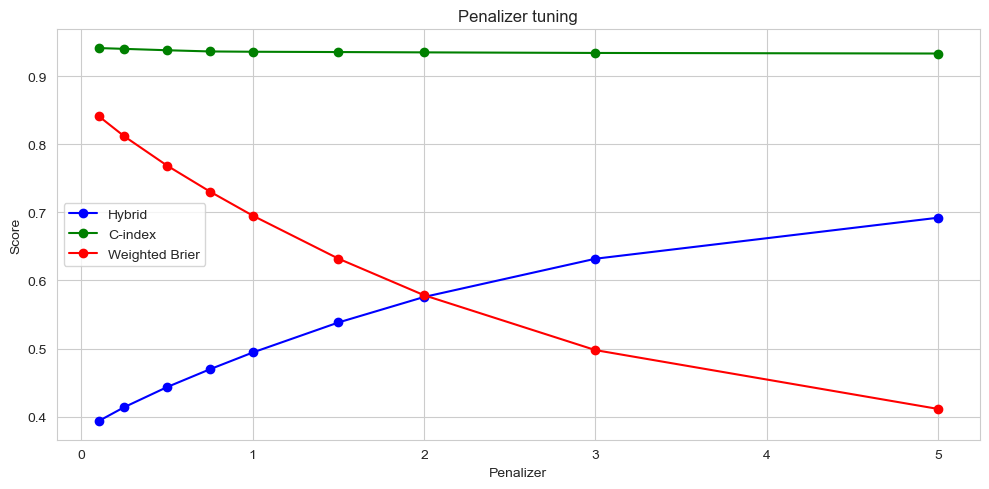

In [100]:

penalizers = [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]
results = []

for p in penalizers:
    utils.PENALIZER = p
    scores, _ = evaluate_features(features, train_best, feature_name=f"penalizer={p}", verbose=False)
    mean_hybrid = np.mean([f['hybrid'] for f in scores])
    mean_cindex = np.mean([f['c_index'] for f in scores])
    mean_brier  = np.mean([f['weighted_brier'] for f in scores])
    results.append((p, mean_hybrid, mean_cindex, mean_brier))
    print(f"penalizer={p:<5} | hybrid={mean_hybrid:.4f} | c_index={mean_cindex:.4f} | wbrier={mean_brier:.4f}")

# Plot
ps, hybrids, cindexes, briers = zip(*results)
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(ps, hybrids, 'b-o', label='Hybrid')
ax1.plot(ps, cindexes, 'g-o', label='C-index')
ax1.plot(ps, briers, 'r-o', label='Weighted Brier')
ax1.set_xlabel('Penalizer')
ax1.set_ylabel('Score')
ax1.legend()
ax1.set_title('Penalizer tuning')
plt.tight_layout()
plt.show()

In [104]:
importlib.reload(utils)
from utils import train_and_submit
test_eval = test.copy()
test_eval['raw_ratio'] = test_eval['num_perimeters_0_5h'] / test_eval['dist_min_ci_0_5h'].replace(0, np.nan)
test_eval['log_ratio_epsilonp'] = np.log(EPSILON + test_eval['raw_ratio'])
test_eval[features] = test_eval[features].replace([np.inf, -np.inf], np.nan)
test_eval[features] = test_eval[features].fillna(feature_medians)  # use training medians

X_test_scaled = scaler_eval.transform(test_eval[features])  # transform only, not fit_transform
test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=test_eval.index)
test_scaled['event_id'] = test_eval['event_id'].values

cph_final, calibrators, submission_final = train_and_submit(
    features,
    train_best,
    test_scaled,
    filename_suffix='_final_penalizer0.1_72h_no_calibrated'
)

TRAINING ON FULL DATA — 2 features

Fitting calibrators on OOF predictions:
  Calibrator @24h: 196 usable rows | 63 hits | base rate 0.321
  Calibrator @48h: 166 usable rows | 66 hits | base rate 0.398
prob_24h — mean=0.278  min=0.000  max=1.000
prob_48h — mean=0.305  min=0.000  max=1.000
prob_72h (proxy) — mean=0.305  min=0.000  max=1.000

Saved: test_submission_final_penalizer0.1_72h_no_calibrated.csv  |  shape: (95, 5)
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602  0.050987  0.001637  0.002651  0.184603
1  13353600  0.362970  0.621244  0.724842  0.827697
2  13942327  0.120909  0.028676  0.045500  0.395004
3  16112781  0.385353  0.676922  0.770849  0.850130
4  17132808  0.343102  0.566749  0.677580  0.805775


In [105]:
print(submission_final[['prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']].describe())

        prob_12h   prob_24h   prob_48h   prob_72h
count  95.000000  95.000000  95.000000  95.000000
mean    0.232778   0.277980   0.305471   0.471911
std     0.258168   0.378846   0.395873   0.334784
min     0.022451   0.000113   0.000183   0.084743
25%     0.043026   0.000938   0.001521   0.157601
50%     0.106097   0.018560   0.029648   0.354273
75%     0.366105   0.629361   0.731664   0.830957
max     0.999829   0.999954   0.999971   1.000000


In [103]:
most_optimal_submission = pd.read_csv('submissions/test_submission_platt_scaled.csv')
print(most_optimal_submission[['prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']].describe())

        prob_12h   prob_24h   prob_48h   prob_72h
count  95.000000  95.000000  95.000000  95.000000
mean    0.232778   0.277980   0.305471   0.471911
std     0.258168   0.378846   0.395873   0.334784
min     0.022451   0.000113   0.000183   0.084743
25%     0.043026   0.000938   0.001521   0.157601
50%     0.106097   0.018560   0.029648   0.354273
75%     0.366105   0.629361   0.731664   0.830957
max     0.999829   0.999954   0.999971   1.000000
